### Matthew Riddell 
### D00245674
### MSc in Data Analytics
### Dissertation
### Data Exploration Jupyter Notebook

Data Exploration conducted after Data Preparation and Cleaning

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

import scipy
from scipy import stats

from scipy.stats import kendalltau
from scipy.stats import spearmanr
from scipy.stats import pearsonr

In [20]:
file_path = "C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/data/Prepared Datasets/"
file_name = "eci_merged_dataset.csv"
complete_file_name = file_path + file_name

In [21]:
merged_data = pd.read_csv(complete_file_name)

In [22]:
merged_data.head(10)

,Country,Signatures,Threshold,Percentage,Petition_ID,Population,GDP,Population_Density,Unemployment_Rate,Tertiary_Enrollment,Life_Expectancy,Urban_Population,Labor_Participation,Signatures_Per_Capita,GDP_Per_Capita,Threshold_Ratio
0,Austria,10724,13395,80.06,eci_table_01,8877067.0,4.463147e+11,109,4.67,85.1,81.6,5194416.0,60.7,0.001208,50277.275087,0.800597
1,Belgium,47459,14805,320.56,eci_table_01,11484055.0,5.296067e+11,383,5.59,79.7,81.6,11259082.0,53.6,0.004133,46116.699234,3.205606
2,Bulgaria,2386,11985,19.91,eci_table_01,6975761.0,8.600000e+10,64,4.34,71.0,74.9,5256027.0,55.4,0.000342,12328.404026,0.199082
3,Croatia,8574,8460,101.35,eci_table_01,4067500.0,6.041555e+10,73,6.93,67.9,78.1,2328318.0,51.2,0.002108,14853.239837,1.013475
4,Cyprus,696,4230,16.45,eci_table_01,1198575.0,2.456465e+10,131,7.27,75.9,80.8,800708.0,63.1,0.000581,20494.877613,0.164539
5,Czech Republic,3774,14805,25.49,eci_table_01,10669709.0,2.464892e+11,139,1.93,64.1,79.0,7887156.0,60.6,0.000354,23101.777705,0.254914
6,Denmark,8587,9870,87.00,eci_table_01,5818553.0,3.480780e+11,137,4.91,80.6,81.0,5119978.0,62.2,0.001476,59822.092961,0.870010
7,Estonia,1519,4935,30.78,eci_table_01,1331824.0,3.138695e+10,31,5.11,69.6,78.2,916024.0,63.6,0.001141,23566.890205,0.307801
8,Finland,23618,9870,239.29,eci_table_01,5520314.0,2.687612e+11,18,6.59,88.2,81.7,4716888.0,59.1,0.004278,48685.853987,2.392908
9,France,580568,55695,1042.41,eci_table_01,67059887.0,2.715518e+12,119,8.43,65.6,82.5,54123364.0,55.1,0.008657,40493.928572,10.424060


In [23]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                135 non-null    object 
 1   Signatures             135 non-null    int64  
 2   Threshold              135 non-null    int64  
 3   Percentage             135 non-null    float64
 4   Petition_ID            135 non-null    object 
 5   Population             135 non-null    float64
 6   GDP                    135 non-null    float64
 7   Population_Density     135 non-null    int64  
 8   Unemployment_Rate      135 non-null    float64
 9   Tertiary_Enrollment    135 non-null    float64
 10  Life_Expectancy        135 non-null    float64
 11  Urban_Population       135 non-null    float64
 12  Labor_Participation    135 non-null    float64
 13  Signatures_Per_Capita  135 non-null    float64
 14  GDP_Per_Capita         135 non-null    float64
 15  Thresh

In [24]:
print("Shape:", merged_data.shape)

Shape: (135, 16)


In [25]:
merged_data.describe()

,Signatures,Threshold,Percentage,Population,GDP,Population_Density,Unemployment_Rate,Tertiary_Enrollment,Life_Expectancy,Urban_Population,Labor_Participation,Signatures_Per_Capita,GDP_Per_Capita,Threshold_Ratio
count,135.000000,135.000000,135.000000,1.350000e+02,1.350000e+02,135.000000,135.000000,135.000000,135.000000,1.350000e+02,135.000000,135.000000,135.000000,135.000000
mean,26359.066667,18408.333333,117.518519,1.657809e+07,5.781803e+11,176.592593,6.042593,71.255556,79.907407,1.238606e+07,58.444444,0.002016,34820.662358,1.175186
std,63547.157854,16977.920143,182.371544,2.194513e+07,8.988865e+11,259.988843,3.247932,19.964172,2.714517,1.688220e+07,3.962825,0.003429,22263.768150,1.823715
min,8.000000,4230.000000,0.110000,5.026530e+05,1.478616e+10,18.000000,1.930000,19.200000,74.700000,4.759020e+05,49.600000,0.000002,12328.404026,0.001114
25%,77.000000,7755.000000,0.590000,2.786844e+06,6.041555e+10,72.000000,3.980000,63.900000,77.600000,1.891013e+06,55.400000,0.000009,19329.096801,0.005858
50%,3774.000000,13395.000000,47.450000,8.877067e+06,2.464892e+11,109.000000,5.360000,70.200000,81.000000,5.256027e+06,59.100000,0.001084,25739.247814,0.474468
75%,23714.000000,20445.000000,166.435000,1.733285e+07,5.308329e+11,139.000000,6.590000,80.600000,82.100000,1.125908e+07,61.600000,0.002733,48685.853987,1.664347
max,580568.000000,67680.000000,1055.110000,8.313280e+07,3.845630e+12,1380.000000,17.240000,136.600000,83.300000,6.432484e+07,64.600000,0.028501,110172.373141,10.551064


In [31]:
print("\nPearson correlation matrix:")
pearson_corr = merged_data.corr(method='pearson', numeric_only=True)
display(pearson_corr)

print("\nSpearman correlation matrix:")
spearman_corr = merged_data.corr(method='spearman', numeric_only=True)
display(spearman_corr)

print("\nKendall's Tau correlation matrix:")
kendall_corr = merged_data.corr(method='kendall', numeric_only=True)
display(kendall_corr)


Pearson correlation matrix:


,Signatures,Threshold,Percentage,Population,GDP,Population_Density,Unemployment_Rate,Tertiary_Enrollment,Life_Expectancy,Urban_Population,Labor_Participation,Signatures_Per_Capita,GDP_Per_Capita,Threshold_Ratio
Signatures,1.000000,0.509319,0.700290,0.518223,0.516363,-0.032923,0.128517,0.018926,0.207533,0.532052,-0.140220,0.332344,0.045835,0.700289
Threshold,0.509319,1.000000,0.153772,0.996678,0.937842,-0.048438,0.178699,0.007127,0.261238,0.985980,-0.307761,-0.107000,-0.018794,0.153768
Percentage,0.700290,0.153772,1.000000,0.157527,0.175977,-0.079908,0.066185,0.103646,0.176259,0.171458,-0.068810,0.865367,0.066956,1.000000
Population,0.518223,0.996678,0.157527,1.000000,0.953559,-0.032074,0.180644,0.002419,0.280749,0.993291,-0.285849,-0.094651,0.001898,0.157523
GDP,0.516363,0.937842,0.175977,0.953559,1.000000,0.016229,0.107794,0.022954,0.372344,0.970793,-0.134201,-0.060032,0.158442,0.175973
Population_Density,-0.032923,-0.048438,-0.079908,-0.032074,0.016229,1.000000,-0.226856,-0.186457,0.298356,-0.013816,-0.102084,0.016597,0.104264,-0.079906
Unemployment_Rate,0.128517,0.178699,0.066185,0.180644,0.107794,-0.226856,1.000000,0.566670,0.315783,0.201126,-0.397667,-0.023446,-0.103766,0.066183
Tertiary_Enrollment,0.018926,0.007127,0.103646,0.002419,0.022954,-0.186457,0.566670,1.000000,0.174995,0.032185,-0.037182,0.033445,-0.214045,0.103643
Life_Expectancy,0.207533,0.261238,0.176259,0.280749,0.372344,0.298356,0.315783,0.174995,1.000000,0.324490,0.023834,0.111746,0.595434,0.176258
Urban_Population,0.532052,0.985980,0.171458,0.993291,0.970793,-0.013816,0.201126,0.032185,0.324490,1.000000,-0.254142,-0.084991,0.038974,0.171455



Spearman correlation matrix:


,Signatures,Threshold,Percentage,Population,GDP,Population_Density,Unemployment_Rate,Tertiary_Enrollment,Life_Expectancy,Urban_Population,Labor_Participation,Signatures_Per_Capita,GDP_Per_Capita,Threshold_Ratio
Signatures,1.000000,0.416251,0.960078,0.420145,0.437839,0.058998,0.058506,0.073067,0.215448,0.421012,-0.135791,0.806626,0.132125,0.960182
Threshold,0.416251,1.000000,0.204103,0.993262,0.875865,0.205290,-0.047027,-0.025200,0.226207,0.988037,-0.325706,-0.144825,0.019361,0.204481
Percentage,0.960078,0.204103,1.000000,0.212941,0.275355,-0.007004,0.089389,0.127782,0.209489,0.216626,-0.055354,0.917603,0.182350,0.999988
Population,0.420145,0.993262,0.212941,1.000000,0.885836,0.222833,-0.020150,0.036020,0.240721,0.993895,-0.331298,-0.137541,0.044567,0.213292
GDP,0.437839,0.875865,0.275355,0.885836,1.000000,0.244200,-0.002137,0.123321,0.496716,0.900488,-0.097710,-0.043610,0.433455,0.275852
Population_Density,0.058998,0.205290,-0.007004,0.222833,0.244200,1.000000,-0.361166,-0.298535,0.295708,0.208791,-0.136183,-0.025649,0.300366,-0.007150
Unemployment_Rate,0.058506,-0.047027,0.089389,-0.020150,-0.002137,-0.361166,1.000000,0.282705,0.313627,-0.014044,-0.213926,0.079435,0.007022,0.089382
Tertiary_Enrollment,0.073067,-0.025200,0.127782,0.036020,0.123321,-0.298535,0.282705,1.000000,0.113945,0.053114,0.207328,0.064158,0.217338,0.127426
Life_Expectancy,0.215448,0.226207,0.209489,0.240721,0.496716,0.295708,0.313627,0.113945,1.000000,0.260883,-0.017571,0.165549,0.773790,0.209456
Urban_Population,0.421012,0.988037,0.216626,0.993895,0.900488,0.208791,-0.014044,0.053114,0.260883,1.000000,-0.299542,-0.132782,0.073871,0.217014



Kendall's Tau correlation matrix:


,Signatures,Threshold,Percentage,Population,GDP,Population_Density,Unemployment_Rate,Tertiary_Enrollment,Life_Expectancy,Urban_Population,Labor_Participation,Signatures_Per_Capita,GDP_Per_Capita,Threshold_Ratio
Signatures,1.000000,0.327762,0.826109,0.324513,0.337543,0.044369,0.033296,0.051558,0.152960,0.324064,-0.090006,0.588626,0.073799,0.825587
Threshold,0.327762,1.000000,0.144107,0.968154,0.756278,0.179506,-0.064832,0.002943,0.151159,0.944612,-0.221335,-0.100524,-0.002943,0.143919
Percentage,0.826109,0.144107,1.000000,0.146707,0.188271,-0.004718,0.059509,0.086946,0.144256,0.148954,-0.033796,0.763818,0.121545,0.999502
Population,0.324513,0.968154,0.146707,1.000000,0.760684,0.185185,-0.051355,0.037037,0.160693,0.954416,-0.214287,-0.093731,0.014245,0.146522
GDP,0.337543,0.756278,0.188271,0.760684,1.000000,0.196581,-0.017118,0.082621,0.361559,0.772080,-0.054286,-0.030869,0.253561,0.188289
Population_Density,0.044369,0.179506,-0.004718,0.185185,0.196581,1.000000,-0.245364,-0.196581,0.235300,0.162393,-0.065715,-0.018073,0.225071,-0.004603
Unemployment_Rate,0.033296,-0.064832,0.059509,-0.051355,-0.017118,-0.245364,1.000000,0.194009,0.221268,-0.062768,-0.137339,0.056206,-0.017118,0.059367
Tertiary_Enrollment,0.051558,0.002943,0.086946,0.037037,0.082621,-0.196581,0.194009,1.000000,0.109042,0.048433,0.117143,0.044340,0.145299,0.086566
Life_Expectancy,0.152960,0.151159,0.144256,0.160693,0.361559,0.235300,0.221268,0.109042,1.000000,0.172171,-0.005755,0.112835,0.562425,0.144071
Urban_Population,0.324064,0.944612,0.148954,0.954416,0.772080,0.162393,-0.062768,0.048433,0.172171,1.000000,-0.202858,-0.091486,0.025641,0.148768


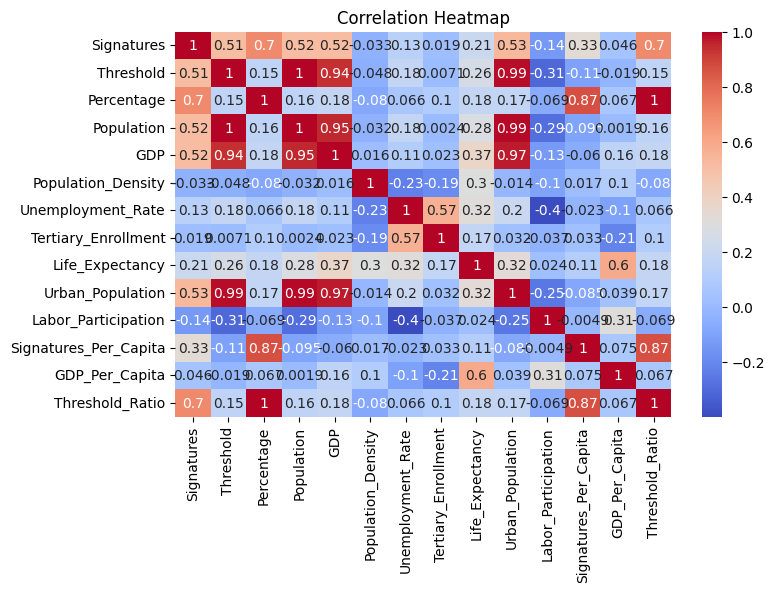

In [30]:
plt.figure(figsize=(8,5))
sns.heatmap(merged_data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

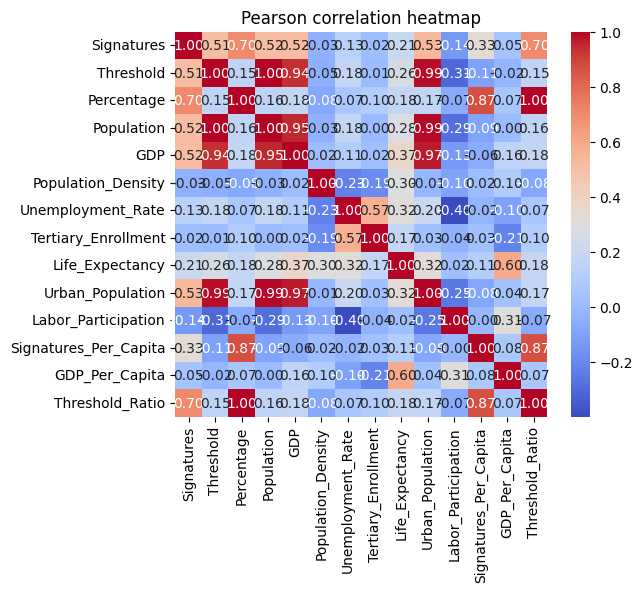

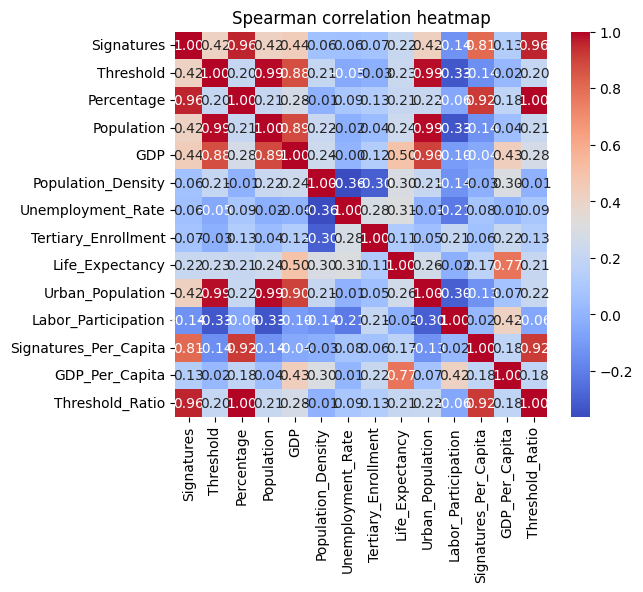

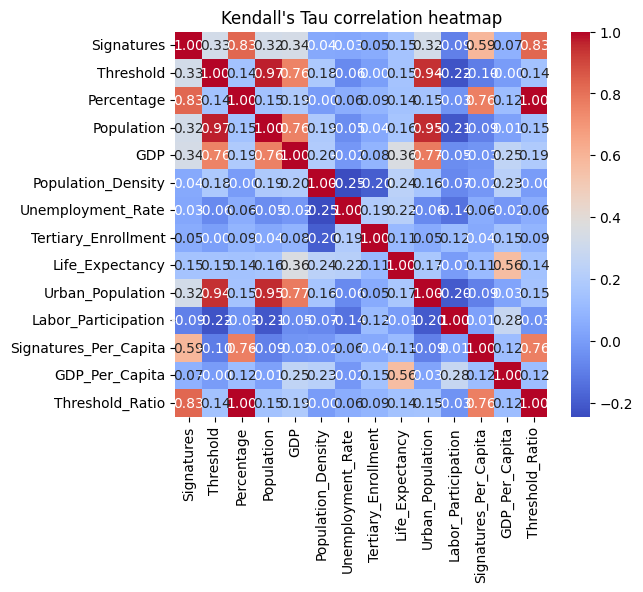

In [32]:
plt.figure(figsize=(6,5))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Pearson correlation heatmap")
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Spearman correlation heatmap")
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Kendall's Tau correlation heatmap")
plt.show()

<Axes: >

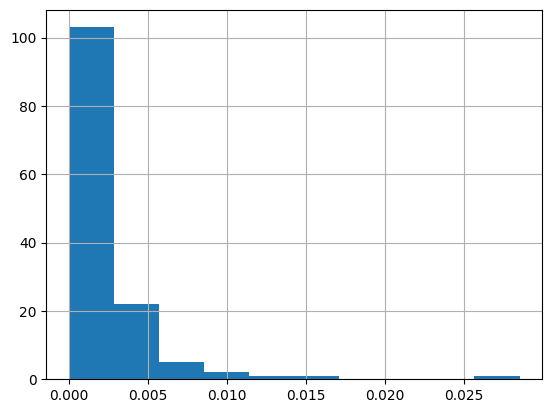

In [28]:
merged_data["Signatures_Per_Capita"].hist()

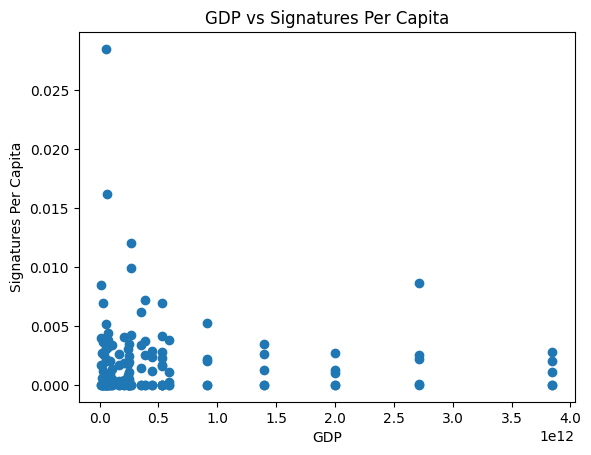

In [29]:
import matplotlib.pyplot as plt

plt.scatter(
    merged_data["GDP"],
    merged_data["Signatures_Per_Capita"]
)

plt.xlabel("GDP")
plt.ylabel("Signatures Per Capita")
plt.title("GDP vs Signatures Per Capita")

plt.show()